# Graph RL for Network Interdiction Problem

Network Interdiction is a two-player problem where one player (red) tries to maximize the total flow of the network and the other team (blue) tries to minimize the flow by removing edges from the graph. Optimal classical solutions exist but due to the combinatorial nature of the problem, they are not viable solutions in most real-world problems. (meta)Heuristic methods provide a compromise between optimality and practicality, however they are still either too slow or too sub-optimal.

DeepRL is an emerging direction which can balance the aforementioned tradeoff. RL offloads the computational requirements to the training phase, providing sufficient solutions at very fast inference speed. Combining Graph Representation Learning with RL allows us to take into consideration network related properties, increase the performance of standard RL methods.

This notebook demonstrates an end-to-end implementation of GraphRL methods on the Network Interdiction Problem using standard deep learning libraries (PyTorch Geometric, StableBaselines3, etc.).

In [2]:
import torch as th
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

from graph_nip.config import ExperimentConfig
from graph_nip.graph_gen import generate_grid_flow_network
from graph_nip.utils import flow_network_to_line_graph_data
from graph_nip.env import NetworkInterdictionEnv
from graph_nip.policy import MLPActionHead
from train import train_ppo, evaluate

### Step 1: Graph Generation
We first generate a directed grid-based flow network to serve as our base environment.

Successfully generated graph with 7 nodes and 7 edges.


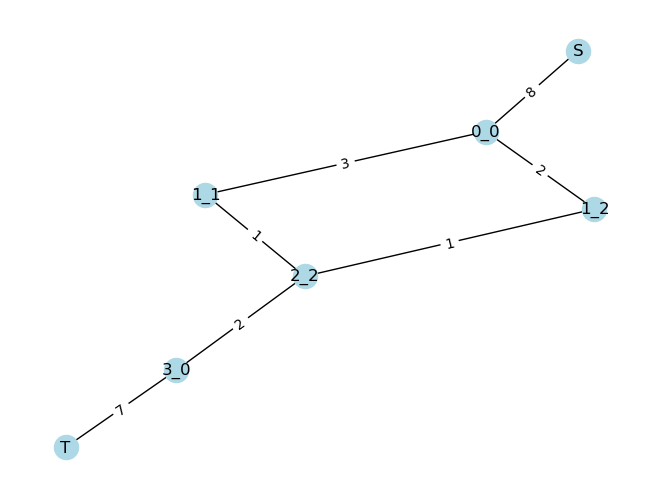

In [2]:
G = generate_grid_flow_network(num_cols=4, nodes_per_col=4, density=0.5, cap_min=1, cap_max=10, seed=None)
print(f"Successfully generated graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Visualize
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'capacity')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

In [3]:
G.edges('S')

EdgeDataView([('S', '0_0')])

### Step 2: Line Graph Transformation
We transform the directed flow network into an undirected line graph. This representation is passed to the Graph Neural Network (GNN).

In [4]:
flow_val, flow_dict = nx.maximum_flow(G, min(G.nodes()), max(G.nodes()), capacity='capacity')
data = flow_network_to_line_graph_data(G, flow_dict, interdicted_edges=set(), remaining_budget_fraction=1.0)
print(f"Line Graph PyG Data:\n Nodes (original edges): {data.x.size(0)}\n Edges (adjacencies): {data.edge_index.size(1)}")
print("Sample node features (cap, interdicted, flow, budget):", data.x[0].numpy())

Line Graph PyG Data:
 Nodes (original edges): 7
 Edges (adjacencies): 18
Sample node features (cap, interdicted, flow, budget): [8. 0. 0. 1.]


### Step 3: Environment Dynamics & Action Masking
We test the environment step logic, ensuring that interdicting an edge correctly reduces the flow, and that invalid actions (already interdicted edges) are masked out.

In [5]:
cfg = ExperimentConfig()
env = NetworkInterdictionEnv(cfg.train_graph_cfg, seed=1)
obs, _ = env.reset()
print(f"Initial Max Flow: {env.initial_max_flow}")

# Select a random valid action
masks = env.action_masks()
valid_actions = np.where(masks)[0]
action = valid_actions[0]

print(f"Selected action (edge index): {action}, Edge: {env.edge_list[action]}")
next_obs, reward, terminated, truncated, info = env.step(action)
print(f"Reward received: {reward:.3f}, New Max Flow: {env.current_max_flow}")

Initial Max Flow: 7
Selected action (edge index): 0, Edge: ('S', '0_0')
Reward received: 0.000, New Max Flow: 7


### Step 4: Policy Network (MLP Action Head)
We verify the custom policy network, which combines the global graph embedding with local node embeddings to produce action logits for each edge.

In [6]:
from torch_geometric.data import Batch
embed_dim = 16
max_nodes = 10
head = MLPActionHead(embed_dim, max_nodes)

# Dummy batch of 2 graphs, with 3 and 4 nodes respectively
dummy_batch = Batch(
    x=th.randn(7, embed_dim),
    graph_attr=th.randn(2, embed_dim),
    batch=th.tensor([0, 0, 0, 1, 1, 1, 1])
)

logits = head(dummy_batch)
print(f"Logits shape: {logits.shape}") # Should be [2, 10]
print("Logits computation successful!")

Logits shape: torch.Size([2, 10])
Logits computation successful!


## Full Pipeline Training
Once all 5 tasks are complete, you can train the agent and plot the learning curves.

In [7]:
import time
from stable_baselines3.common.results_plotter import load_results, ts2xy
import os

networks = ["GAT", "GCN", "GraphSAGE"]
run_ids = {}
models = {}

for net in networks:
    print(f"--- Training {net} ---")
    run_id = int(time.time())
    run_ids[net] = run_id
    
    config = ExperimentConfig()
    config.policy_cfg.network = net
    config.train_cfg.timesteps = 15000  # Small number for demo

    # Create Envs
    def make_env(is_eval=False, seed_offset=0):
        def _init():
            return NetworkInterdictionEnv(config.train_graph_cfg, seed=config.train_cfg.seed + seed_offset, is_eval=is_eval)
        return _init

    train_env = VecMonitor(DummyVecEnv([make_env(is_eval=False, seed_offset=0)]))
    val_env = VecMonitor(DummyVecEnv([make_env(is_eval=True, seed_offset=10)]))

    models[net] = train_ppo(train_env, val_env, config, run_id)
    time.sleep(1) # Ensure unique run_id

--- Training GAT ---
Creating PPO model with GAT...
Using cpu device
Starting training for 15000 timesteps...
Logging to runs/1783578795/PPO_1


/Users/vj/miniconda3/envs/rl/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/vj/miniconda3/envs/rl/lib/python3.12/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.07     |
|    ep_rew_mean     | 0.402    |
| time/              |          |
|    fps             | 260      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------


Eval num_timesteps=2048, episode_reward=0.64 +/- 0.25

...

Eval num_timesteps=14336, episode_reward=0.97 +/- 0.07

Episode length: 4.60 +/- 1.50

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 4.6          |
|    mean_reward          | 0.97         |
| time/                   |              |
|    total_timesteps      | 14336        |
| train/                  |              |
|    approx_kl            | 0.0037261657 |
|    clip_fraction        | 0.00664      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.91        |
|    explained_variance   | 0.468        |
|    learning_rate        | 0.0001       |
|    loss                 | 0.0251       |
|    n_updates            | 130          |
|    policy_gradient_loss | -0.00672     |
|    value_loss           | 0.0797       |
------------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.11     |
|    ep_rew_mean     | 0.766    |
| time/              |          |
|    fps             | 55       |
|    iterations      | 14       |
|    time_elapsed    | 256      |
|    total_timesteps | 14336    |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.09         |
|    ep_rew_mean          | 0.739        |
| time/                   |              |
|    fps                  | 55           |
|    iterations           | 15           |
|    time_elapsed         | 275          |
|    total_timesteps      | 15360        |
| train/                  |              |
|    approx_kl            | 0.0032333005 |
|    clip_fraction        | 0.00811      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.86        |
|    explained_variance   | 0.53         |
|    learning_r

In [ ]:
# Plotly Learning Curve Visualization
import os
import plotly.graph_objects as go
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def plot_learning_curve_tb(run_ids_dict):
    fig = go.Figure()
    
    for net, run_id in run_ids_dict.items():
        log_folder = f"runs/{run_id}/PPO_1"
        if not os.path.exists(log_folder):
            print(f"Log folder {log_folder} not found for {net}.")
            continue
            
        tf_files = [os.path.join(log_folder, f) for f in os.listdir(log_folder) if 'tfevents' in f]
        if not tf_files:
            continue
            
        event_acc = EventAccumulator(tf_files[0])
        event_acc.Reload()
        
        if 'rollout/ep_rew_mean' not in event_acc.Tags()['scalars']:
            continue
            
        rewards_events = event_acc.Scalars('rollout/ep_rew_mean')
        x = [e.step for e in rewards_events]
        y = [e.value for e in rewards_events]
        
        fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name=f'{net} Episode Reward', line=dict(width=2)))
        
    fig.update_layout(title="Learning Curve Comparison", xaxis_title='Timesteps', yaxis_title='Mean Reward', template='plotly_white')
    fig.show()


plot_learning_curve_tb(run_ids)

In [10]:
# Performance vs Graph Size Evaluation
import plotly.graph_objects as go

sizes = [8, 12, 16, 20, 40, 60]
eval_results = {}

config = ExperimentConfig()
# Increase max line graph nodes dynamically to accommodate larger evaluation graphs without broadcasting errors
config.train_graph_cfg.max_line_graph_nodes = max(100, max(sizes) * 4)

for net, run_id in run_ids.items():
    print(f"Evaluating {net}...")
    res = evaluate(run_id, config, sizes)
    eval_results[net] = res

fig = go.Figure()

for net, res in eval_results.items():
    if res is None: continue
    mean_rewards = [res[s] for s in sizes]
    fig.add_trace(go.Bar(
        x=[f"~{s} nodes" for s in sizes],
        y=mean_rewards,
        name=net
    ))

fig.update_layout(
    title="Agent Performance vs Inference Graph Size Comparison",
    xaxis_title="Graph Size",
    yaxis_title="Mean Normalized Reward",
    template='plotly_white',
    barmode='group',
    yaxis=dict(range=[0, 1.1])
)
fig.show()

Evaluating GAT...

--- Evaluating Models on different graph sizes ---

Evaluating on graphs of ~8 nodes...
Size 8 | Mean Reward: 0.660 +/- 0.402

Evaluating on graphs of ~12 nodes...
Size 12 | Mean Reward: 0.845 +/- 0.308

Evaluating on graphs of ~16 nodes...
Size 16 | Mean Reward: 0.936 +/- 0.144

Evaluating on graphs of ~20 nodes...
Size 20 | Mean Reward: 0.976 +/- 0.063

Evaluating on graphs of ~40 nodes...
Size 40 | Mean Reward: 0.966 +/- 0.092

Evaluating on graphs of ~60 nodes...
Size 60 | Mean Reward: 1.000 +/- 0.000
Evaluating GCN...

--- Evaluating Models on different graph sizes ---

Evaluating on graphs of ~8 nodes...
Size 8 | Mean Reward: 0.597 +/- 0.391

Evaluating on graphs of ~12 nodes...
Size 12 | Mean Reward: 0.938 +/- 0.222

Evaluating on graphs of ~16 nodes...
Size 16 | Mean Reward: 0.875 +/- 0.236

Evaluating on graphs of ~20 nodes...
Size 20 | Mean Reward: 0.933 +/- 0.119

Evaluating on graphs of ~40 nodes...
Size 40 | Mean Reward: 0.991 +/- 0.041

Evaluating on gr